# Tratamento da Estação Bangu

Este notebook organiza o tratamento horário da Estação `Bangu` em três blocos simples:

1. Padronizar o calendário horário;
2. Interpolar apenas lacunas internas curtas;
3. Validar o impacto do tratamento.

A proposta aqui é fazer o básico bem feito, de forma rastreável e reutilizável para as próximas estações.


## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da estação

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da estação para evitar problemas de codificação e isolamos apenas os registros da estação `Bangu`.


In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_bangu = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO BANGU"].copy()

df_bangu["data"] = pd.to_datetime(df_bangu["data"])
df_bangu = df_bangu.sort_values("data").reset_index(drop=True)
df_bangu = df_bangu.drop_duplicates(subset="data", keep="first")
df_bangu = df_bangu.set_index("data").sort_index().copy()

print("Dimensoes da base da Estacao Bangu:", df_bangu.shape)
display(df_bangu.head())

Dimensoes da base da Estacao Bangu: (61368, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,ESTAÇÃO BANGU,0.2,24.67,95.24,NaN,15.18,0.42,2.18,17.36,28.06,81.0,NaN,-22.88791,-43.471074
2012-01-01 01:30:00,ESTAÇÃO BANGU,0.4,24.72,94.13,0.40,9.50,0.35,1.63,11.12,32.81,61.0,NaN,-22.88791,-43.471074
2012-01-01 02:30:00,ESTAÇÃO BANGU,0.0,24.49,92.91,0.12,8.74,0.27,1.73,10.47,31.61,26.0,NaN,-22.88791,-43.471074
2012-01-01 03:30:00,ESTAÇÃO BANGU,0.2,24.54,92.59,0.00,5.51,0.21,1.18,6.68,37.39,20.0,NaN,-22.88791,-43.471074
2012-01-01 04:30:00,ESTAÇÃO BANGU,0.4,24.78,90.71,0.00,8.41,0.16,0.95,9.35,33.45,7.0,NaN,-22.88791,-43.471074


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de dados faltantes antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.


In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_bangu, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
pm2_5,61368,100.00,0
temp,17176,27.99,44192
so2,7498,12.22,53870
pm10,6798,11.08,54570
co,4236,6.90,57132
nox,4094,6.67,57274
no2,4081,6.65,57287
no,3912,6.37,57456
o3,3613,5.89,57755
ur,3341,5.44,58027


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- Interpolar apenas lacunas internas de até `4` horas consecutivas;
- Não extrapolar bordas da série;
- Não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.


In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_bangu_tratado = df_bangu.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_bangu[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_bangu_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"



    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_bangu_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
2,so2,interpolate_time,7498,4909,2589
0,no,interpolate_time,3912,2087,1825
1,no2,interpolate_time,4081,2268,1813
4,nox,interpolate_time,4094,2289,1805
9,pm10,interpolate_time,6798,5983,815
7,o3,interpolate_time,3613,3121,492
8,co,interpolate_time,4236,3783,453
5,ur,interpolate_time,3341,3029,312
6,temp,interpolate_time,17176,17080,96
3,pm2_5,interpolate_time,61368,61368,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- Redução dos dados faltantes por variável;
- Estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir parte das lacunas sem alterar, de forma relevante, o comportamento geral das séries.


Total de valores imputados: 10200


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
so2,7498,12.22,4909,8.00,2589,34.53
no,3912,6.37,2087,3.40,1825,46.65
no2,4081,6.65,2268,3.70,1813,44.43
nox,4094,6.67,2289,3.73,1805,44.09
pm10,6798,11.08,5983,9.75,815,11.99
o3,3613,5.89,3121,5.09,492,13.62
co,4236,6.90,3783,6.16,453,10.69
ur,3341,5.44,3029,4.94,312,9.34
temp,17176,27.99,17080,27.83,96,0.56
pm2_5,61368,100.00,61368,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
no,6.310484,3.02,10.214359,6.205259,2.950000,10.120479,-0.105225,-0.093880
no2,23.600638,19.88,15.705009,23.402129,19.670000,15.634566,-0.198509,-0.070443
so2,2.837628,1.95,4.383757,2.832014,1.960000,4.330852,-0.005614,-0.052905
nox,29.903006,23.49,22.574194,29.597941,23.220000,22.440191,-0.305065,-0.134003
ur,67.631855,69.31,17.872595,67.675475,69.350000,17.906534,0.043620,0.033939
temp,26.607594,25.97,4.790516,26.610201,25.980000,4.789895,0.002607,-0.000621
o3,47.152134,40.87,36.940620,47.272632,41.050000,36.929996,0.120498,-0.010623
co,0.359583,0.31,0.231276,0.359721,0.313333,0.230918,0.000138,-0.000358
pm10,35.496372,30.00,25.301079,35.530821,30.000000,25.344932,0.034449,0.043853
chuva,0.145603,0.00,1.324437,0.145603,0.000000,1.324437,0.000000,0.000000


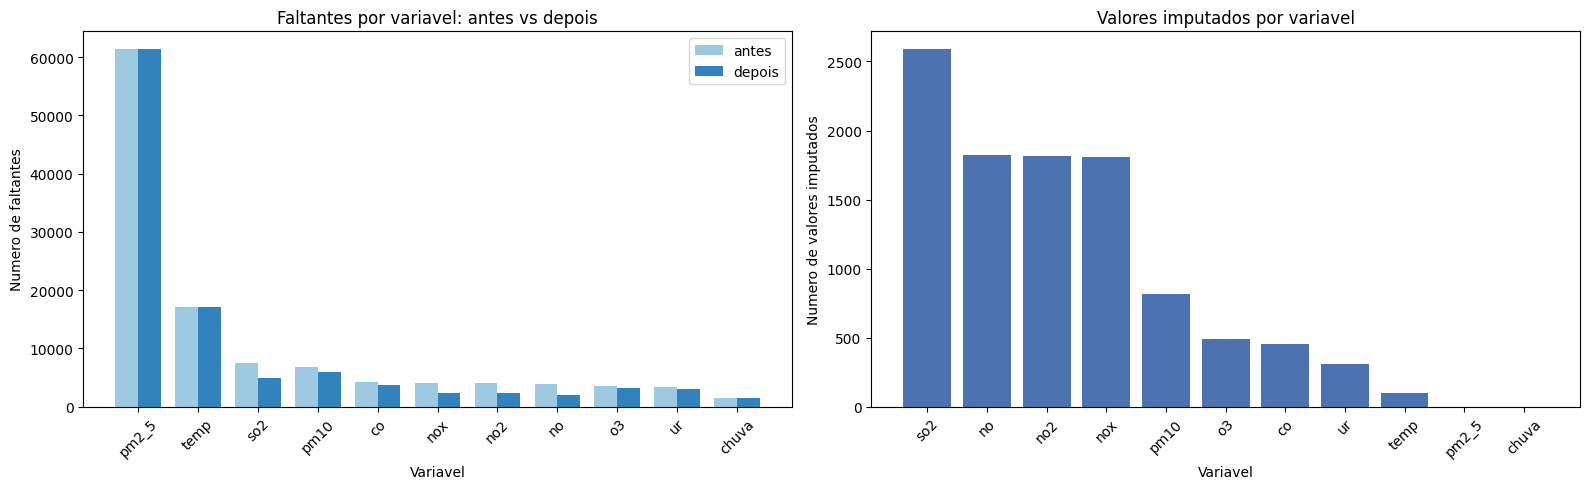

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_bangu_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_bangu[variavel].notna().any() or df_bangu_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_bangu, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_bangu_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a Estação `Bangu`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_bangu_diario = (
    df_bangu_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

df_bangu_diario_saida = df_bangu_diario.reset_index()
output_csv_diario_path = output_dir / "bangu_tratado_diario.csv"
df_bangu_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_bangu_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\bangu_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,2.452500,11.238750,0.470435,NaN,13.689167,90.205833,25.777083,29.651667,0.473333,20.312500,30.0
1,2012-01-02,4.909583,14.019583,0.396667,NaN,18.923750,94.847500,22.667917,19.629167,0.246250,5.416667,44.6
2,2012-01-03,7.156250,13.562083,0.518958,NaN,20.719583,74.360000,25.159583,23.405000,0.367292,21.208333,0.0
3,2012-01-04,14.143333,29.517083,0.770417,NaN,43.661667,70.591667,26.500417,29.161053,0.390417,40.875000,0.4
4,2012-01-05,6.610000,20.611250,0.337083,NaN,27.200000,70.697917,27.385417,45.120833,0.450000,28.625000,0.0


## Resumo interpretativo do tratamento

O tratamento aplicado na estação `Bangu` manteve uma estratégia conservadora (interpolação temporal em lacunas curtas, até `4` horas) e aumentou a completude sem alterar, de forma relevante, o comportamento geral das séries. No total, foram imputados `10200` valores, com maior contribuição em `so2` (`2589`), `no` (`1825`), `no2` (`1813`) e `nox` (`1805`), seguidos por `pm10` (`815`).

As reduções de dados faltantes foram mais fortes em `no` (`6,37%` para `3,40%`), `no2` (`6,65%` para `3,70%`) e `nox` (`6,67%` para `3,73%`), além de `so2` (`12,22%` para `8,00%`). Também houve melhora em `pm10`, `o3`, `co` e `ur`, enquanto `temp` teve ganho pequeno (`27,99%` para `27,83%`), indicando predomínio de lacunas longas nessa variável.

Em contrapartida, `pm2_5` permaneceu com `100%` de dados faltantes e `chuva` ficou sem imputação. A comparação estatística antes e depois mostra variações pequenas em `média`, `mediana` e `desvio_padrao` nas variáveis observadas, sugerindo ganho de completude com baixo risco de distorção da distribuição original.
